# 2.3.1 从收支率到一阶初值问题

## 学习目标与先修知识

能从持续收支（mass balance）推导一阶常微分方程（ordinary differential equation，ODE），求出恒定输入（input）解析解（analytical solution），并核对初值（initial condition）、方程和零清除等边界。

先修：上一章的导数（derivative）、定积分（definite integral）、指数、对数和链式法则（chain rule）。 [复习上一节](../02-变化率与累积微积分入口/03-指数对数与链式法则.ipynb)。

## 具体问题

均匀物质池持续流入、持续清除。若每一瞬间清除速率都随当前所追踪物质总量（tracked amount）改变，应怎样摆脱“冻结一个时间段”的假设？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
A0,u,k=0,1,.5
for h in [1,.5,.1]:
    value=A0
    for _ in range(round(2/h)):
        value+=h*(u-k*value)
    print(f'h={h:g} T, A(2) ≈ {value:.8f} U')

h=1 T, A(2) ≈ 1.50000000 U
h=0.5 T, A(2) ≈ 1.36718750 U
h=0.1 T, A(2) ≈ 1.28302816 U


## 模型假设

边界内瞬时混合均匀，只有外部输入 u 与一阶清除 kA；u、k 在观察区间恒定。A 用 U，u 用 U/T，k 用 1/T，t 用 T。这里的 k 是一阶消除速率常数（first-order elimination rate constant）：它乘以当前总量 A，得到当前消除流率（flow rate）kA（U/T）；后文可简称消除系数或清除系数（elimination rate constant）。它不是单独的消除流率，也不是药代动力学中单位为 V/T 的清除率 CL。参数（parameter）是教学选值。排除饱和清除、组织交换和空间梯度；所求函数在区间内可微。

## 数学解释与推导

由一小段收支有 $[A(t+h)-A(t)]/h\approx u-kA(t)$。当段宽趋近零且速率连续，得到
$$\frac{dA}{dt}=u-kA,\qquad A(0)=A_0.$$
方程只包含时间这一自变量的导数，称常微分方程；最高只有一阶导数，所以是一阶。方程加初值才构成初值问题（initial value problem），解是一整条满足两者的函数，不是单个终点。

先取 u=0、A0>0。对 A>0，分离变量：$dA/A=-kdt$。分别从 A0 到 A(t)、0 到 t 积分，得到 $\ln[A(t)/A_0]=-kt$，所以 $A=A_0e^{-kt}$。对数作用于无量纲（dimensionless）比值。A0=0 的零解单独核对，不能在推导时除以零。

一般的 k>0 情形先找平衡（equilibrium） $A^*=u/k$，再令 $x=A-A^*$，得到 $x'=-kx$。当 x(0) 非零时，积分得 $\ln|x(t)/x(0)|=-kt$，符号由初值保持；x=0 也直接满足方程。因此
$$A(t)=A^*+(A_0-A^*)e^{-kt}=A_0e^{-kt}+\frac uk(1-e^{-kt}).$$
将它求导，得到 $A'=(u-kA_0)e^{-kt}=u-kA(t)$；t=0 时为 A0。两个检查缺一不可。

k=0 时方程成为 A′=u，单独得到 $A=A_0+ut$。若 k 很小，$1-e^{-kt}$ 中相近数相减可能损失精度。等价写法
$$A(t)=A_0e^{-kt}-\frac uk\operatorname{expm1}(-kt)$$
利用 `math.expm1(z)` 准确计算 $e^z-1$，保留 k→0 的连续极限（limit）。等价代数式的浮点表现可能不同。

实现时再令 z=−kt，改写为 $A=A_0e^z+ut\,[\operatorname{expm1}(z)/z]$。z 趋于零时，方括号内的比值趋于 1。这样既避免两个相近数相减，也不先形成可能过大的 u/k；z=0 时直接用比值 1。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def exact_amount(time, u, k, A0):
    import math
    if k == 0:
        return A0 + u * time
    # expm1(z)/z tends to 1; this avoids both cancellation and a huge u/k.
    z = -k * time
    ratio = 1.0 if z == 0 else math.expm1(z) / z
    return A0 * math.exp(z) + u * time * ratio

def exact_series(A0, u, k, times):
    return [exact_amount(t, u, k, A0) for t in times]

## 对照实验

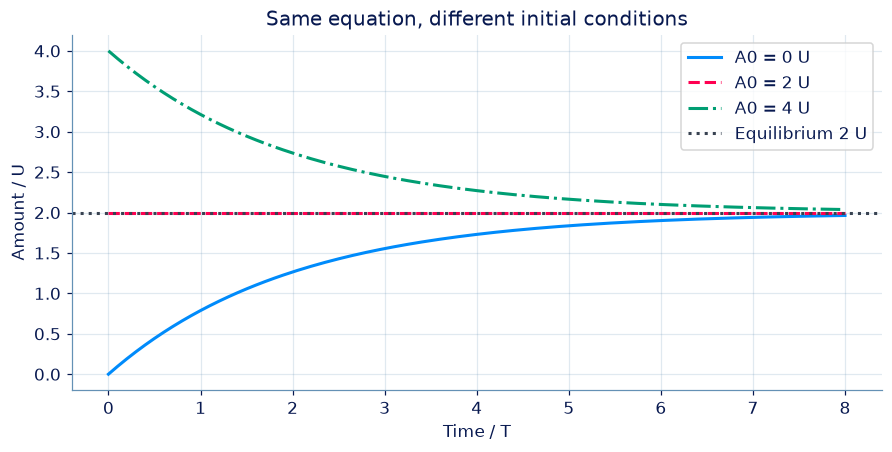

| 实现 | A(1) / U |
| --- | --- |
| 直接相减 | 2.9992 |
| expm1 | 3 |
| 零清除极限 | 3 |

In [4]:
times=np.linspace(0,8,161)
fig,ax=plt.subplots()
for initial,style in [(0,'-'),(2,'--'),(4,'-.')]:
    ax.plot(times,exact_series(initial,1,.5,times),style,label=f'A0 = {initial} U')
ax.axhline(2,color='#384251',ls=':',label='Equilibrium 2 U')
ax.set(xlabel='Time / T',ylabel='Amount / U',title='Same equation, different initial conditions');ax.legend();plt.show()
small=1e-14
stable=exact_amount(1,1,small,2)
naive=2*math.exp(-small)+(1/small)*(1-math.exp(-small))
display(Markdown(show_table(['实现','A(1) / U'],[('直接相减',naive),('expm1',stable),('零清除极限',3)])))

## 结果解释

三个起点朝同一个平衡靠近，其中恰好位于平衡的轨迹（trajectory）保持不变。靠近的方向由 A0−A* 的符号决定。极小 k 的表格暴露了直接相减造成的误差；稳定表达接近零清除极限 3 U。

### 独立核对

解析求导给理论依据，中心差分（central difference）提供数值交叉核对；零清除分支还有独立的线性收支表达。

In [5]:
for initial,u,k in [(0,1,.5),(10,0,.75),(2,1,.5),(3,2,0)]:
    assert math.isclose(exact_amount(0,u,k,initial),initial,abs_tol=1e-12)
    for t in [1,2,5]:
        h=1e-5
        slope=(exact_amount(t+h,u,k,initial)-exact_amount(t-h,u,k,initial))/(2*h)
        assert math.isclose(slope,u-k*exact_amount(t,u,k,initial),abs_tol=2e-9)
assert abs(exact_amount(1,1,1e-14,2)-3)<1e-12
assert exact_amount(2,3,0,2)==8
print('初值、方程残差、零清除及极小系数边界通过。')

初值、方程残差、零清除及极小系数边界通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-03-连续时间与一阶微分方程/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：方程还缺什么

已知 dA/dt=u−kA，u、k 为常数。为了唯一确定本例轨迹（trajectory），还必须提供什么？

- **A.** 一个起始时刻及该时刻所追踪物质总量（tracked amount）。
- **B.** 只需画一条看起来平滑的曲线。
- **C.** 所有未来时刻的真实测量。
- **D.** 任意一个时间步长（time step）即可代替初值（initial condition）。

[作答：方程还缺什么](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-ivp)

### 第 2 题 · Python 计算题：恒定输入的连续解

理想单室模型（one-compartment model）满足 dA/dt=u−kA，A(0)=A0。返回指定时刻的解析所追踪物质总量（tracked amount）。包含 k=0 和很小 k，需避免两个近乎相等的数相减损失精度。

**函数与代码模板**

```python
def solve(
    A0: float,
    u: float,
    k: float,
    times: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 初始总量。 | U |
| `u` | `float` | 恒定输入（input）速率。 | U/T |
| `k` | `float` | 非负清除系数（elimination rate constant）。 | 1/T |
| `times` | `list[float]` | 非负时刻，保留给定顺序。 | T |

**返回值**

直接返回 amounts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 各时刻的解析总量。 | U |

**计算规则**

k=0 时 A=A0+u*t；k>0 时 A=A0*exp(−k*t)−(u/k)*expm1(−k*t)。math.expm1(z) 准确计算 exp(z)−1。

**约束与边界**

- 所有数值有限；无需修改输入。
- 0 ≤ A0,u ≤ 20；k=0 或 1e−14 ≤ k ≤ 2；0 ≤ times[i] ≤ 20；列表长度 0—1000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 初始总量。 | 0 | U |
| u | 恒定输入（input）速率。 | 1 | U/T |
| k | 非负清除系数（elimination rate constant）。 | 0.5 | 1/T |
| times | 非负时刻，保留给定顺序。 | [0, 2] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 0
u = 1
k = 0.5
times = [0, 2]

result = solve(A0, u, k, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| amounts | 各时刻的解析总量。 | [0.0, 1.2642411176571153] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 1.2642411176571153]
```

**样例解释**

平衡（equilibrium）量为 2 U，A(2)=2(1−exp(−1))≈1.2642411177 U；起点为 0。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：恒定输入的连续解](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-exact)

### 第 3 题 · 多项选择题：减去平衡为什么有用

对 k>0，令 A*=u/k，x=A−A*。哪些推导成立？

- **A.** 因为 A* 为常数，x′=A′。
- **B.** x′=−kx。
- **C.** 任何初值（initial condition）都必须等于 A*。
- **D.** x(t)=(A0−A*)exp(−kt)。

[作答：减去平衡为什么有用](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-shift-equilibrium)

### 第 4 题 · 单项选择题：不能除以零的分支

若 k=0、u=2 U/T、A0=3 U，则下面哪项成立？

- **A.** 平衡（equilibrium）为 u/k，应设为无限大并直接计算。
- **B.** A(t)=3+2t，没有有限恒定平衡。
- **C.** A(t)=3exp(−2t)。
- **D.** A(t)=0。

[作答：不能除以零的分支](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-zero-clearance)

**进一步阅读**

[MIT 一阶微分方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/)：分离变量与线性方程；[Python expm1](https://docs.python.org/3/library/math.html#math.expm1)：近零参数的浮点计算。